In [1]:
import torch
import torch.nn as nn
import sys
import hls4ml

COMMON_PATH = "../../Common/VAENet"

In [2]:
class vae_encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),  # Increased channels, stride 2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AvgPool2d((4, 8)),
        )
        self.mu = nn.Linear(256, 6)  # Reduced latent space size
        self.std = nn.Linear(256, 6)  # Reduced latent space size

    def forward(self, x):
        a = self.encoder(x)
        a = torch.flatten(a, 1)
        mu = self.mu(a)
        lvar = self.std(a)
        out = torch.cat((mu, lvar), dim=1)
        return out

model = vae_encoder()
model.load_state_dict(torch.load(f'{COMMON_PATH}/pre_trained_w_encoder.pt', weights_only=True))

<All keys matched successfully>

In [3]:
config = hls4ml.utils.config_from_pytorch_model(
    model, 
    input_shape=(3, 128, 256),
    granularity='model', 
    backend='catapult',
    )
print("-----------------------------------")
print("Configuration")
print(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_pytorch_model(
    model, hls_config=config,
    backend='catapult',  # 'Vivado' or 'Vitis' or 'Intel'
    output_dir='vitis_hls/hls4ml_prj',
)

-----------------------------------
Configuration
{'Model': {'Precision': {'default': 'ap_fixed<16,6>'}, 'ReuseFactor': 1, 'ChannelsLastConversion': 'full', 'TransposeOutputs': False, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}, 'PytorchModel': vae_encoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_runn

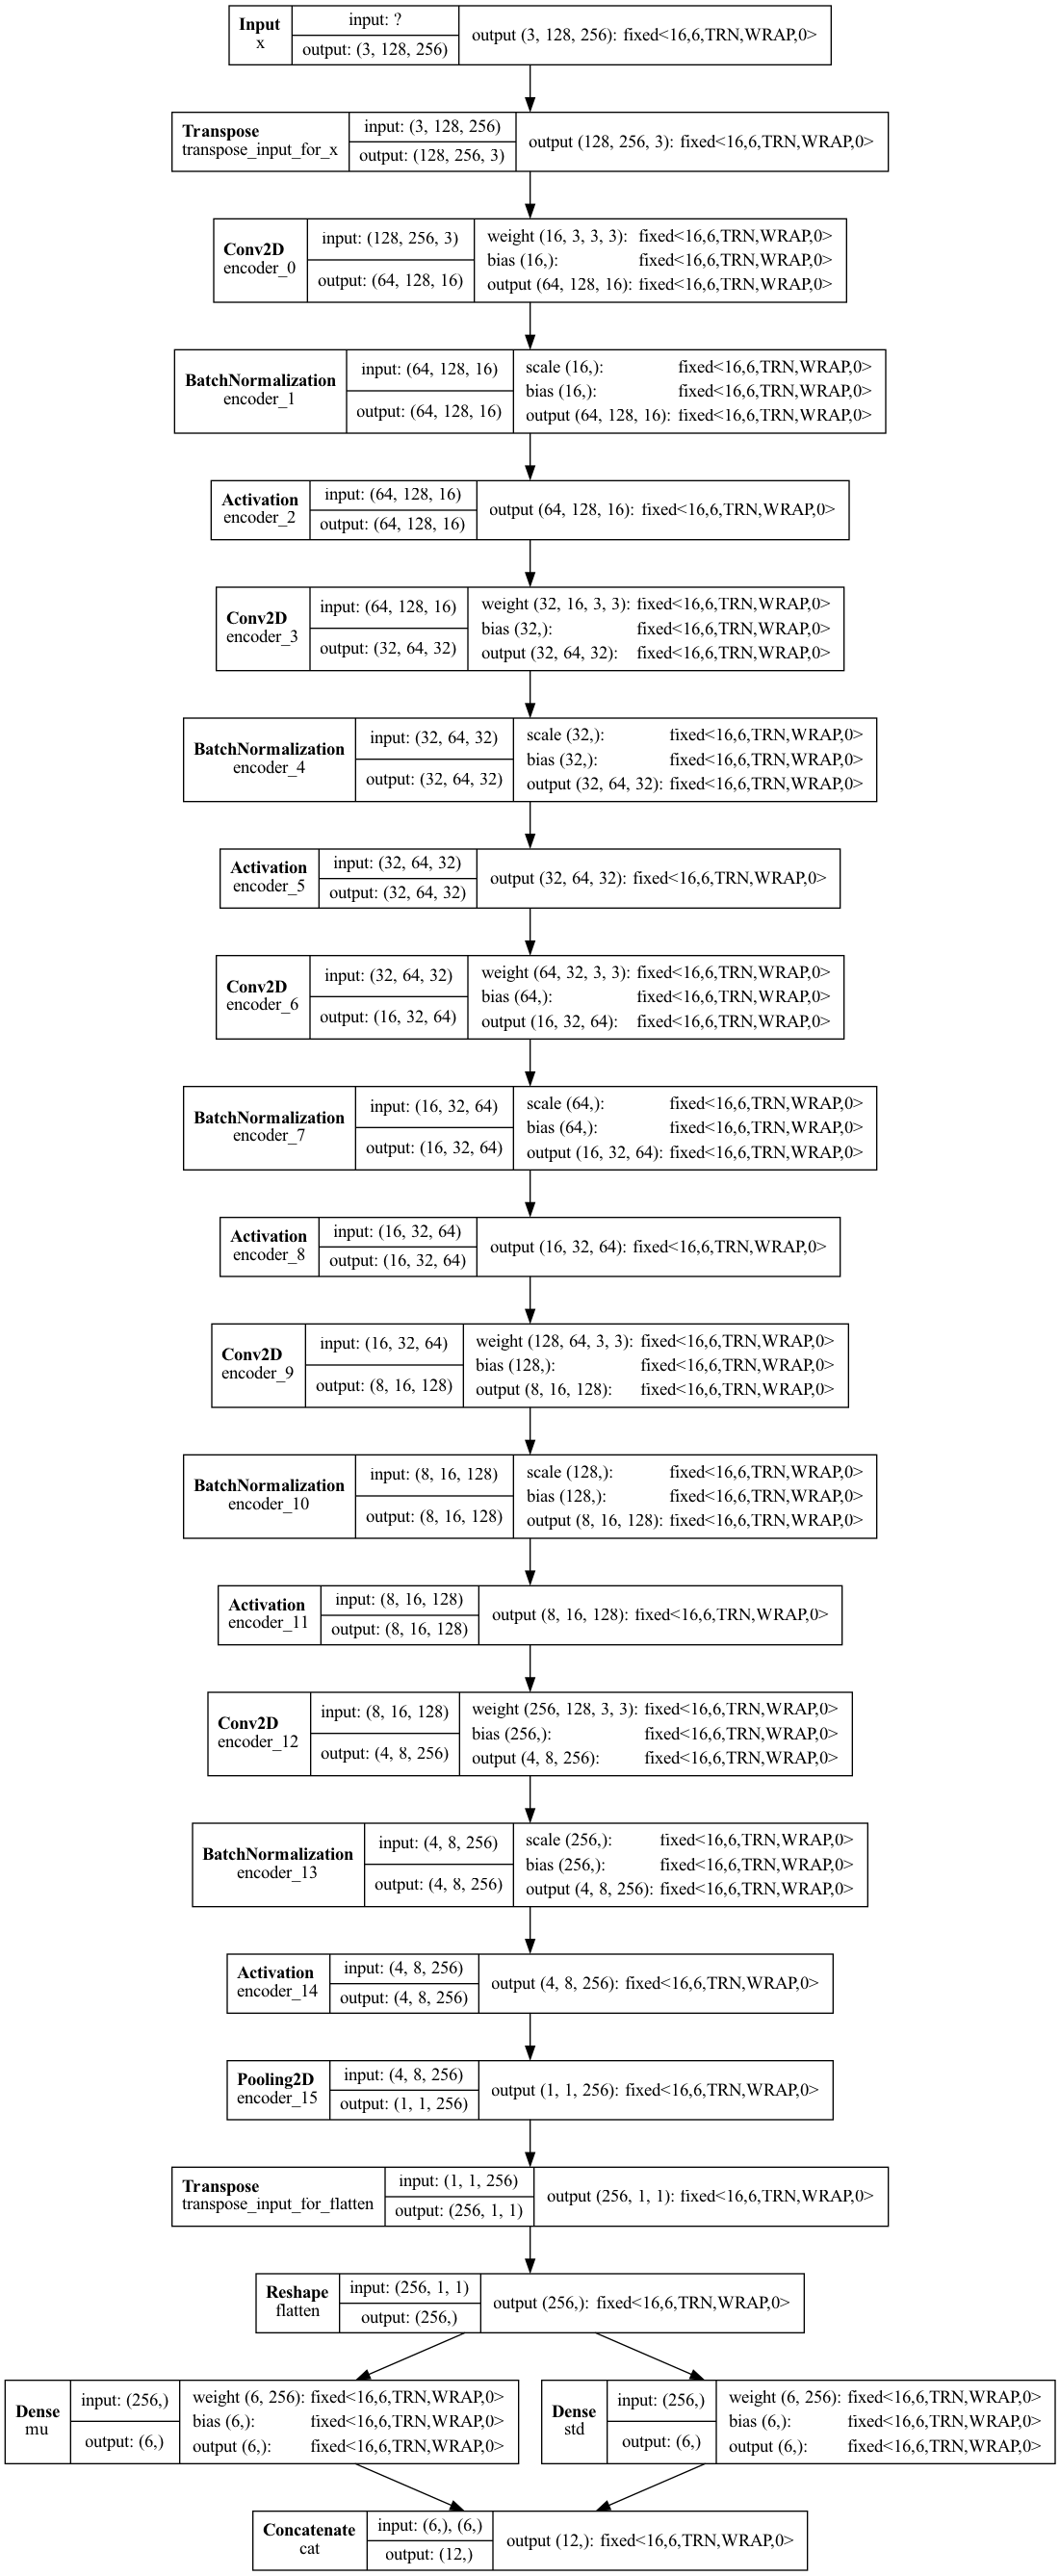

In [4]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [5]:
hls_model.compile()

Writing HLS project
Copying NNET files to local firmware directory
... copying AC ac_types headers from /opt/anaconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/writer/../templates/catapult/ac_types/
... copying AC ac_math headers from /opt/anaconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/writer/../templates/catapult/ac_math/
... copying AC ac_simutils headers from /opt/anaconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/writer/../templates/catapult/ac_simutils/
Done
